***Importing libraries***

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score

# Data Preprocessing

***Reading the dataset***

In [2]:
file_path_train = r'C:\Users\User\Desktop\Main\7 semester\ML\spotify_songs.csv'
df_train = pd.read_csv(file_path_train)
df_train.head()

,track_id,track_name,track_artist,track_popularity,track_album_id,track_album_name,track_album_release_date,playlist_name,playlist_id,playlist_genre,...,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
0,6f807x0ima9a1j3VPbc7VN,I Don't Care (with Justin Bieber) - Loud Luxur...,Ed Sheeran,66,2oCs0DGTsRO98Gh5ZSl2Cx,I Don't Care (with Justin Bieber) [Loud Luxury...,2019-06-14,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,6,-2.634,1,0.0583,0.1020,0.000000,0.0653,0.518,122.036,194754
1,0r7CVbZTWZgbTCYdfa2P31,Memories - Dillon Francis Remix,Maroon 5,67,63rPSO264uRjW1X5E6cWv6,Memories (Dillon Francis Remix),2019-12-13,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,11,-4.969,1,0.0373,0.0724,0.004210,0.3570,0.693,99.972,162600
2,1z1Hg7Vb0AhHDiEmnDE79l,All the Time - Don Diablo Remix,Zara Larsson,70,1HoSmj2eLcsrR0vE9gThr4,All the Time (Don Diablo Remix),2019-07-05,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,1,-3.432,0,0.0742,0.0794,0.000023,0.1100,0.613,124.008,176616
3,75FpbthrwQmzHlBJLuGdC7,Call You Mine - Keanu Silva Remix,The Chainsmokers,60,1nqYsOef1yKKuGOVchbsk6,Call You Mine - The Remixes,2019-07-19,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,7,-3.778,1,0.1020,0.0287,0.000009,0.2040,0.277,121.956,169093
4,1e8PAfcKUYoKkxPhrHqw4x,Someone You Loved - Future Humans Remix,Lewis Capaldi,69,7m7vv9wlQ4i0LFuJiE2zsQ,Someone You Loved (Future Humans Remix),2019-03-05,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,1,-4.672,1,0.0359,0.0803,0.000000,0.0833,0.725,123.976,189052


***Data preprocessing***

In [3]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32833 entries, 0 to 32832
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   track_id                  32833 non-null  object 
 1   track_name                32828 non-null  object 
 2   track_artist              32828 non-null  object 
 3   track_popularity          32833 non-null  int64  
 4   track_album_id            32833 non-null  object 
 5   track_album_name          32828 non-null  object 
 6   track_album_release_date  32833 non-null  object 
 7   playlist_name             32833 non-null  object 
 8   playlist_id               32833 non-null  object 
 9   playlist_genre            32833 non-null  object 
 10  playlist_subgenre         32833 non-null  object 
 11  danceability              32833 non-null  float64
 12  energy                    32833 non-null  float64
 13  key                       32833 non-null  int64  
 14  loudne

In [4]:
df_train.describe()

,track_popularity,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
count,32833.000000,32833.000000,32833.000000,32833.000000,32833.000000,32833.000000,32833.000000,32833.000000,32833.000000,32833.000000,32833.000000,32833.000000,32833.000000
mean,42.477081,0.654850,0.698619,5.374471,-6.719499,0.565711,0.107068,0.175334,0.084747,0.190176,0.510561,120.881132,225799.811622
std,24.984074,0.145085,0.180910,3.611657,2.988436,0.495671,0.101314,0.219633,0.224230,0.154317,0.233146,26.903624,59834.006182
min,0.000000,0.000000,0.000175,0.000000,-46.448000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4000.000000
25%,24.000000,0.563000,0.581000,2.000000,-8.171000,0.000000,0.041000,0.015100,0.000000,0.092700,0.331000,99.960000,187819.000000
50%,45.000000,0.672000,0.721000,6.000000,-6.166000,1.000000,0.062500,0.080400,0.000016,0.127000,0.512000,121.984000,216000.000000
75%,62.000000,0.761000,0.840000,9.000000,-4.645000,1.000000,0.132000,0.255000,0.004830,0.248000,0.693000,133.918000,253585.000000
max,100.000000,0.983000,1.000000,11.000000,1.275000,1.000000,0.918000,0.994000,0.994000,0.996000,0.991000,239.440000,517810.000000


In [5]:
df_train.duplicated().sum()

0

***Checking the number of unique values of each column***

In [6]:
for col in df_train.columns:
    print(col, len(df_train[col].unique()))

track_id 28356
track_name 23450
track_artist 10693
track_popularity 101
track_album_id 22545
track_album_name 19744
track_album_release_date 4530
playlist_name 449
playlist_id 471
playlist_genre 6
playlist_subgenre 24
danceability 822
energy 952
key 12
loudness 10222
mode 2
speechiness 1270
acousticness 3731
instrumentalness 4729
liveness 1624
valence 1362
tempo 17684
duration_ms 19785


***Dropping the unimportant columns***

In [7]:
df_train.drop(columns=['track_id', 'track_name', 'track_artist', 'track_album_id', 'track_album_name', 'track_album_release_date',
                       'playlist_id', 'playlist_name', 'playlist_subgenre', 'instrumentalness'], axis=1, inplace=True)

***Vizualizing distribution of values***

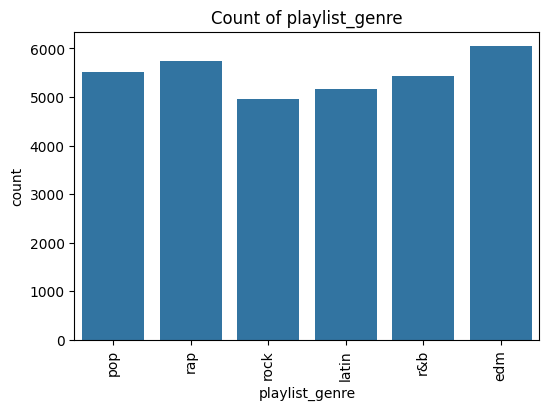

In [8]:
for column_name in df_train.columns:
    if df_train[column_name].dtype == 'object':
        plt.figure(figsize=(6, 4))  
        sns.countplot(x=column_name, data=df_train)
        plt.title(f'Count of {column_name}')
        plt.xticks(rotation=90) 
        plt.show()

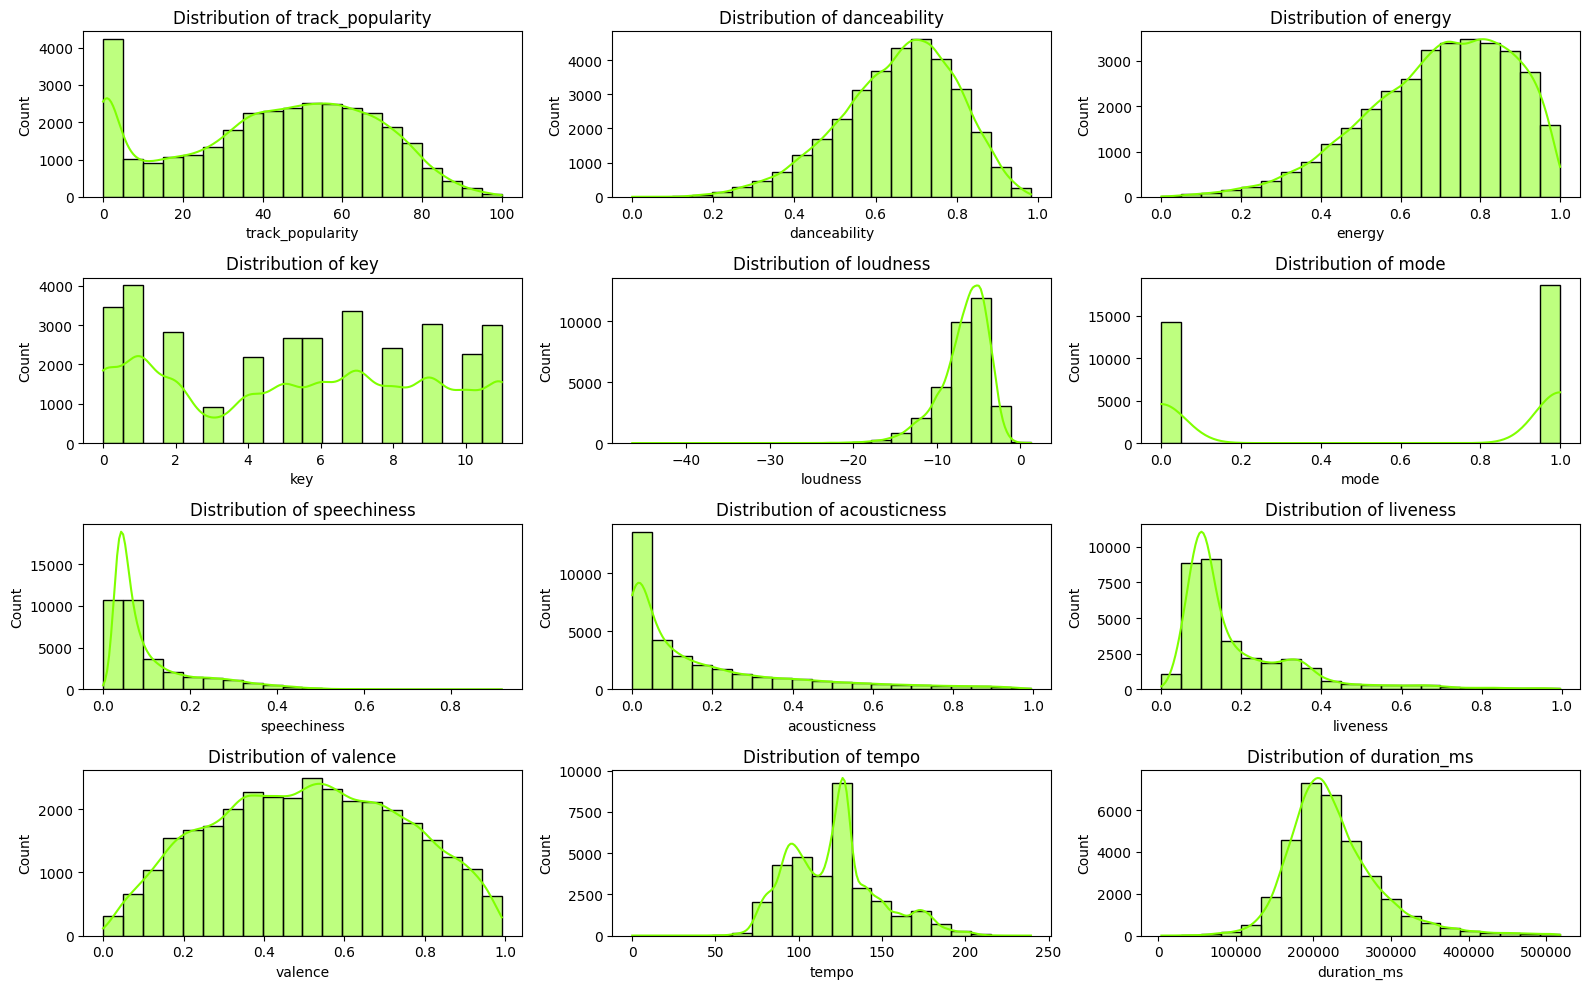

In [9]:
numerical_cols = df_train.select_dtypes(include=['int64', 'float64']).columns
plt.figure(figsize=(16, 10))
for i, col in enumerate(numerical_cols, 1):
    plt.subplot(4, 3, i)
    sns.histplot(df_train[col], kde=True, bins=20, color='chartreuse')
    plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

***Dealing with null values***

In [10]:
df_train.isnull().sum()

track_popularity    0
playlist_genre      0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
liveness            0
valence             0
tempo               0
duration_ms         0
dtype: int64

***Dealing with outliers***

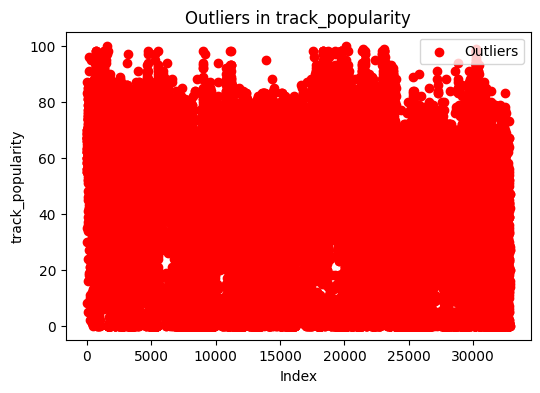

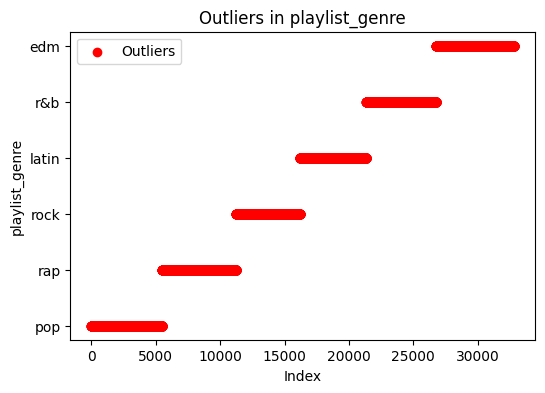

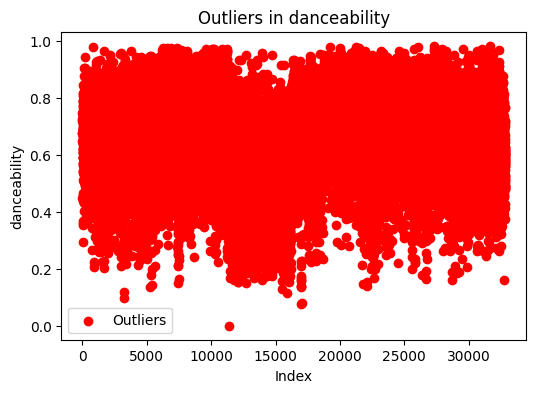

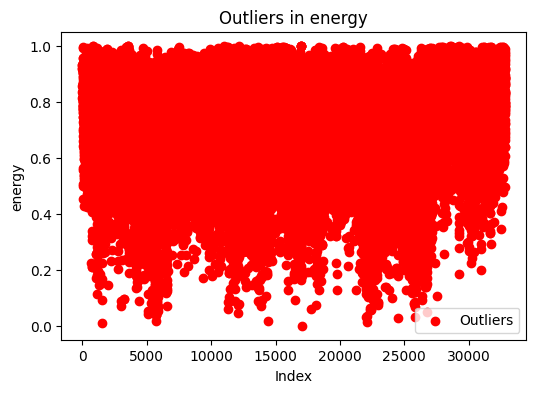

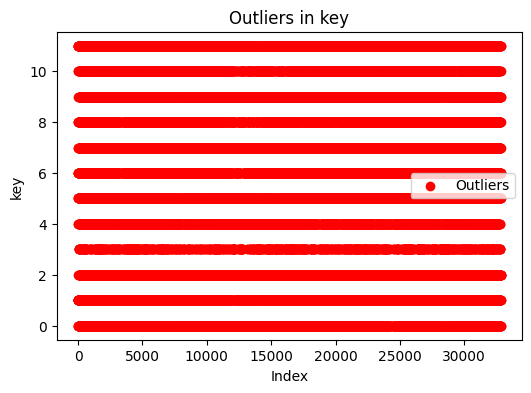

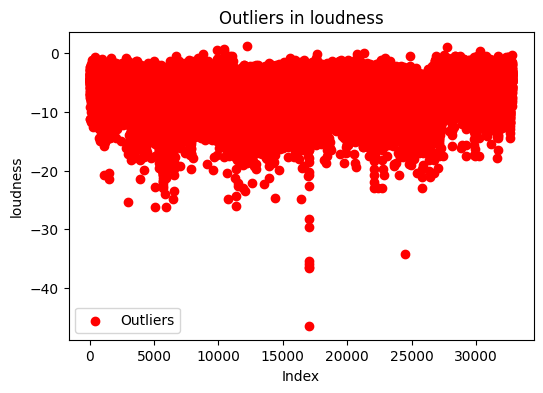

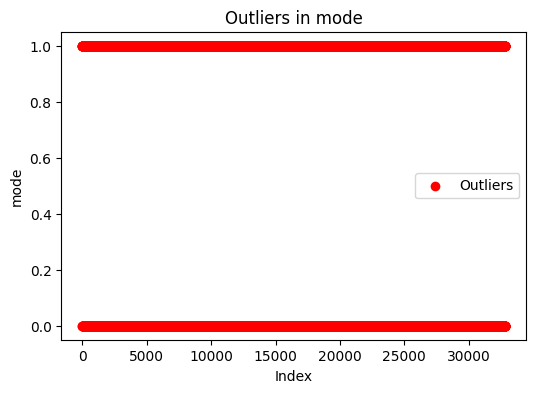

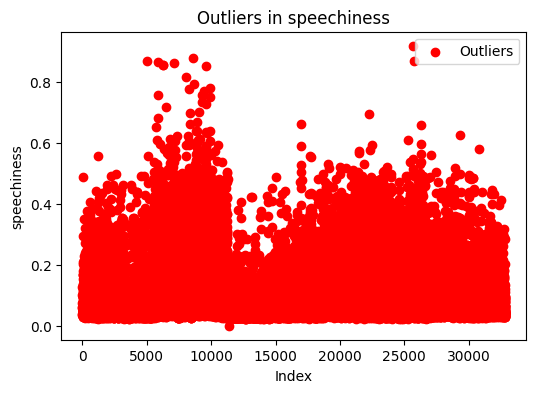

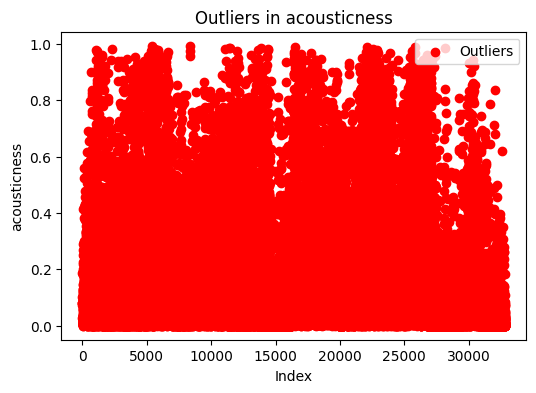

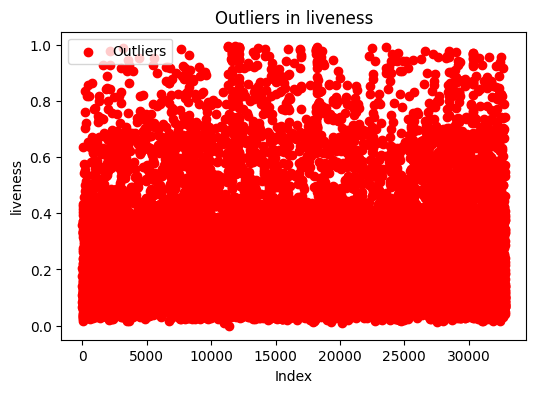

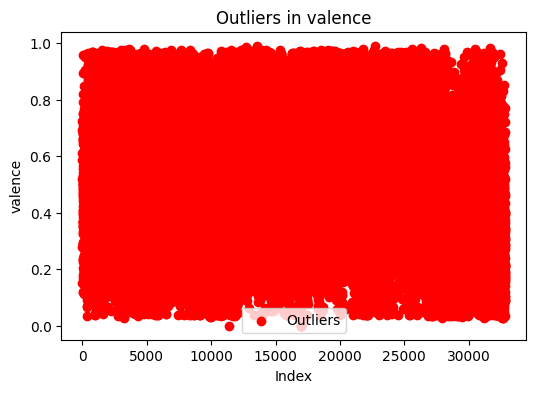

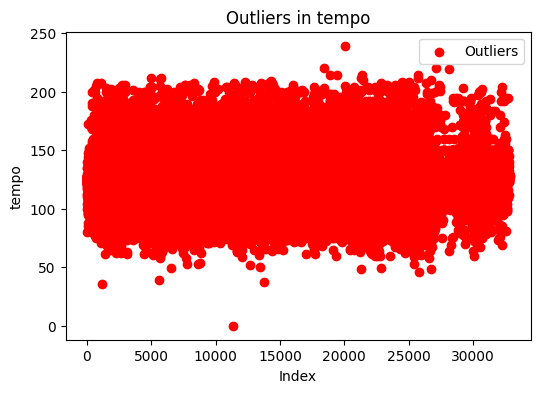

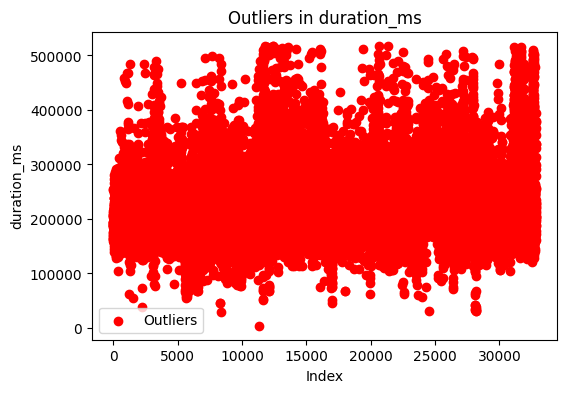

In [11]:
# Plotting outliers for each column
for column in df_train.columns:
    plt.figure(figsize=(6, 4))
    plt.scatter(range(len(df_train)), df_train[column], color='red', label='Outliers')
    plt.xlabel('Index')
    plt.ylabel(column)
    plt.title(f'Outliers in {column}')
    plt.legend()
    plt.show()

In [12]:
from scipy import stats

z_threshold = 3

columns = ['danceability', 'loudness', 'speechiness', 'tempo']

for col in columns:
    z_scores = np.abs(stats.zscore(df_train[col]))
    df_train = df_train[z_scores <= z_threshold]

print(f"Data without Outliers:\n{df_train}")

Data without Outliers:
       track_popularity playlist_genre  danceability  energy  key  loudness  \
0                    66            pop         0.748   0.916    6    -2.634   
1                    67            pop         0.726   0.815   11    -4.969   
2                    70            pop         0.675   0.931    1    -3.432   
3                    60            pop         0.718   0.930    7    -3.778   
4                    69            pop         0.650   0.833    1    -4.672   
...                 ...            ...           ...     ...  ...       ...   
32828                42            edm         0.428   0.922    2    -1.814   
32829                20            edm         0.522   0.786    0    -4.462   
32830                14            edm         0.529   0.821    6    -4.899   
32831                15            edm         0.626   0.888    2    -3.361   
32832                27            edm         0.603   0.884    5    -4.571   

       mode  speechiness  ac

***Obtaining train&test dataframes***

In [13]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

df_train['playlist_genre'] = label_encoder.fit_transform(df_train['playlist_genre'])

In [14]:
Y = df_train['playlist_genre']
X = df_train.drop('playlist_genre', axis=1)

In [15]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_normalized = scaler.fit_transform(X)

In [16]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_normalized, Y, test_size=0.3, random_state=42)

# 10 Models

In [17]:
# Saving all predictions for each model
models_pred = {}

***Decision Tree Classifier***

In [18]:
from sklearn.tree import DecisionTreeClassifier

# Create a decision tree classifier
clf = DecisionTreeClassifier(random_state=42)

# Train the classifier on the training data
clf.fit(X_train, y_train)

# Make predictions on the test set
y_pred_dt = clf.predict(X_test)

# Calculating evaluation metrics
accuracy_dt = accuracy_score(y_test, y_pred_dt)
print(f"Accuracy of the Decision tree classifier model: {accuracy_dt}")

Accuracy of the Decision tree classifier model: 0.4153051544218404


In [19]:
from sklearn.model_selection import GridSearchCV

# Define the parameters you want to search through
param_grid = {
    'max_depth': list(range(1, 31)),
    'min_samples_split': list(range(2, 10))}


# Perform Grid Search with cross-validation
grid_search = GridSearchCV(clf, param_grid, cv=5)
grid_search.fit(X_train, y_train)

best_params = grid_search.best_params_

best_clf = DecisionTreeClassifier(**best_params, random_state=42)
best_clf.fit(X_train, y_train)

# Make predictions on the test set
y_pred_dt_rs = best_clf.predict(X_test)

# Calculating evaluation metrics
accuracy_dt_rs = accuracy_score(y_test, y_pred_dt_rs)
print(f"Accuracy of the Decision tree classifier model: {accuracy_dt_rs} \n \nObtained by these parameters: {best_params}")

Accuracy of the Decision tree classifier model: 0.47106566880995043 
 
Obtained by these parameters: {'max_depth': 9, 'min_samples_split': 5}


In [20]:
models_pred['DecisionTreeClassifier'] = [y_pred_dt, y_pred_dt_rs]

***SVM model***

In [21]:
from sklearn.svm import SVC

# Create an SVM classifier
svm_model = SVC(kernel='linear')

# Train the SVM model
svm_model.fit(X_train, y_train)

# Make predictions
y_pred_svm = svm_model.predict(X_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred_svm)
print(f"Accuracy of the SVM model: {accuracy}")

Accuracy of the SVM model: 0.46168441024559925


In [22]:
# Define the parameters you want to search through
param_grid = {
    'C': [0.1, 1, 3],
    'kernel': ['linear', 'rbf']}

# Perform Grid Search with cross-validation
grid_search = GridSearchCV(svm_model, param_grid, cv=5)
grid_search.fit(X_train, y_train)

best_params = grid_search.best_params_

best_svm = SVC(**best_params)
best_svm.fit(X_train, y_train)

# Make predictions on the test set
y_pred_svm_rs = best_svm.predict(X_test)

# Calculating evaluation metrics
accuracy_svm_rs = accuracy_score(y_test, y_pred_svm_rs)
print(f"Accuracy of the SVM model: {accuracy_svm_rs} \n \nObtained by these parameters: {best_params}")

Accuracy of the SVM model: 0.5305154421840413 
 
Obtained by these parameters: {'C': 3, 'kernel': 'rbf'}


In [23]:
models_pred['SVM'] = [y_pred_svm, y_pred_svm_rs]

***kNN model***

In [24]:
from sklearn.neighbors import KNeighborsClassifier

# Initialize the kNN classifier
k = 3  # Specify the number of neighbors
knn = KNeighborsClassifier(n_neighbors=k)

# Fit the classifier to the training data
knn.fit(X_train, y_train)

# Predict on the test set
y_pred_knn = knn.predict(X_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred_knn)
print(f"Accuracy of the kNN model with k={k}: {accuracy}")

Accuracy of the kNN model with k=3: 0.4212079687994097


In [25]:
# Define the parameters you want to search through
param_grid = {
    'n_neighbors': [3, 5, 7],
    'weights': ['uniform', 'distance']}

# Perform Grid Search with cross-validation
grid_search = GridSearchCV(knn, param_grid, cv=5)
grid_search.fit(X_train, y_train)

best_params = grid_search.best_params_

best_knn = KNeighborsClassifier(**best_params)
best_knn.fit(X_train, y_train)

# Make predictions on the test set
y_pred_knn_rs = best_knn.predict(X_test)

# Calculating evaluation metrics
accuracy_knn_rs = accuracy_score(y_test, y_pred_knn_rs)
print(f"Accuracy of the kNN model: {accuracy_knn_rs} \n \nObtained by these parameters: {best_params}")

Accuracy of the kNN model: 0.46463581743438387 
 
Obtained by these parameters: {'n_neighbors': 7, 'weights': 'distance'}


In [26]:
models_pred['kNN'] = [y_pred_knn, y_pred_knn_rs]

***Logistic Regression***

In [27]:
from sklearn.linear_model import LogisticRegression

# Initialize the logistic regression model
logreg = LogisticRegression()

# Fit the model to the training data
logreg.fit(X_train, y_train)

# Predict on the test set
y_pred_lr = logreg.predict(X_test)
models_pred['LogisticRegression'] = y_pred_lr

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred_lr)
print(f"Accuracy of the Logistic Regression model: {accuracy}")

Accuracy of the Logistic Regression model: 0.4576789290608201


In [28]:
# Define the parameters you want to search through
param_grid = {
    'solver': ['liblinear', 'saga'],
    'max_iter': [100, 200, 300]}

# Perform Grid Search with cross-validation
grid_search = GridSearchCV(logreg, param_grid, cv=5)
grid_search.fit(X_train, y_train)

best_params = grid_search.best_params_

best_logreg = LogisticRegression(**best_params)
best_logreg.fit(X_train, y_train)

# Make predictions on the test set
y_pred_logreg_rs = best_logreg.predict(X_test)

# Calculating evaluation metrics
accuracy = accuracy_score(y_test, y_pred_logreg_rs)
print(f"Accuracy of the LogisticRegression model: {accuracy} \n \nObtained by these parameters: {best_params}")

Accuracy of the LogisticRegression model: 0.4576789290608201 
 
Obtained by these parameters: {'max_iter': 100, 'solver': 'saga'}


In [29]:
models_pred['LogisticRegression'] = [y_pred_lr, y_pred_logreg_rs]

***Naive Bayes***

In [30]:
from sklearn.naive_bayes import GaussianNB

# Initialize the Naive Bayes model
nb = GaussianNB()

# Train the model
nb.fit(X_train, y_train)

# Predict on test set
y_pred_nb = nb.predict(X_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred_nb)
print(f"Accuracy of the Naive Bayes model: {accuracy}")

Accuracy of the Naive Bayes model: 0.44439759671128914


In [31]:
# Create a pipeline with CountVectorizer (example) and MultinomialNB
param_grid = {
    'var_smoothing': np.logspace(0,-9, num=100)}

# Initialize GridSearchCV
grid_search = GridSearchCV(nb, param_grid, cv=5)

# Fit the grid search to the data
grid_search.fit(X_train, y_train)
best_params = grid_search.best_params_

best_nb = GaussianNB(**best_params)
best_nb.fit(X_train, y_train)

# Make predictions on the test set
y_pred_nb_rs = best_nb.predict(X_test)

# Calculating evaluation metrics
accuracy = accuracy_score(y_test, y_pred_nb_rs)
print(f"Accuracy of the Gaussian NB model: {accuracy} \n \nObtained by these parameters: {best_params}")

Accuracy of the Gaussian NB model: 0.4442921893116897 
 
Obtained by these parameters: {'var_smoothing': 0.0015199110829529332}


In [32]:
models_pred['NaiveBayes'] = [y_pred_nb, y_pred_nb_rs]

***Quadratic Discriminant Analysis***

In [33]:
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis

# Initialize the Quadratic Discriminant Analysis model
qda = QuadraticDiscriminantAnalysis()

# Train the model
qda.fit(X_train, y_train)

# Predict on test set
y_pred_qda = qda.predict(X_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred_qda)
print(f"Accuracy of the Quadratic Discriminant Analysis model: {accuracy}")

Accuracy of the Quadratic Discriminant Analysis model: 0.47412248339833457


In [34]:
# Create a pipeline with CountVectorizer (example) and MultinomialNB
param_grid = {
    'reg_param': [0.0, 0.1, 0.2],
    'tol': [0.0001, 0.001, 0.01]
}

# Initialize GridSearchCV
grid_search = GridSearchCV(qda, param_grid, cv=5)

# Fit the grid search to the data
grid_search.fit(X_train, y_train)
best_params = grid_search.best_params_

best_qda = QuadraticDiscriminantAnalysis(**best_params)
best_qda.fit(X_train, y_train)

# Make predictions on the test set
y_pred_qda_rs = best_qda.predict(X_test)

# Calculating evaluation metrics
accuracy = accuracy_score(y_test, y_pred_qda_rs)
print(f"Accuracy of the Quadratic Discriminant Analysis model: {accuracy} \n \nObtained by these parameters: {best_params}")

Accuracy of the Quadratic Discriminant Analysis model: 0.47412248339833457 
 
Obtained by these parameters: {'reg_param': 0.0, 'tol': 0.0001}


In [35]:
models_pred['QuadraticDiscriminantAnalysis'] = [y_pred_qda, y_pred_qda_rs]

***Gradient Boosting Classifier***

In [36]:
from sklearn.ensemble import GradientBoostingClassifier

# Initialize the Gradient Boosting Classifier model
gb = GradientBoostingClassifier()

# Train the model
gb.fit(X_train, y_train)

# Predict on test set
y_pred_gbc = gb.predict(X_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred_gbc)
print(f"Accuracy of the Gradient Boosting Classifier model: {accuracy}")

Accuracy of the Gradient Boosting Classifier model: 0.5392642563507958


In [37]:
# Create a pipeline with CountVectorizer (example) and MultinomialNB
param_grid = {
    'n_estimators': [50, 100],
    'learning_rate': [0.01, 0.1]
}

# Initialize GridSearchCV
grid_search = GridSearchCV(gb, param_grid, cv=5)

# Fit the grid search to the data
grid_search.fit(X_train, y_train)
best_params = grid_search.best_params_

best_gb = GradientBoostingClassifier(**best_params)
best_gb.fit(X_train, y_train)

# Make predictions on the test set
y_pred_gb_rs = best_gb.predict(X_test)

# Calculating evaluation metrics
accuracy = accuracy_score(y_test, y_pred_gb_rs)
print(f"Accuracy of the Gradient Boosting Classifier model: {accuracy} \n \nObtained by these parameters: {best_params}")

Accuracy of the Gradient Boosting Classifier model: 0.5393696637503953 
 
Obtained by these parameters: {'learning_rate': 0.1, 'n_estimators': 100}


In [38]:
models_pred['GradientBoostingClassifier'] = [y_pred_gbc, y_pred_gb_rs]

***Random Forest Classifier***

In [39]:
from sklearn.ensemble import RandomForestClassifier

# Initialize the Random Forest Classifier model
rf = RandomForestClassifier()

# Train the model
rf.fit(X_train, y_train)

# Predict on test set
y_pred_rf = rf.predict(X_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred_rf)
print(f"Accuracy of the Random Forest Classifier model: {accuracy}")

Accuracy of the Random Forest Classifier model: 0.5447454411299674


In [40]:
# Create a pipeline with CountVectorizer (example) and MultinomialNB
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, None]
}

# Initialize GridSearchCV
grid_search = GridSearchCV(rf, param_grid, cv=5)

# Fit the grid search to the data
grid_search.fit(X_train, y_train)
best_params = grid_search.best_params_

best_rf = RandomForestClassifier(**best_params)
best_rf.fit(X_train, y_train)

# Make predictions on the test set
y_pred_rf_rs = best_rf.predict(X_test)

# Calculating evaluation metrics
accuracy = accuracy_score(y_test, y_pred_rf_rs)
print(f"Accuracy of the Random Forest Classifier model: {accuracy} \n \nObtained by these parameters: {best_params}")

Accuracy of the Random Forest Classifier model: 0.5487509223147465 
 
Obtained by these parameters: {'max_depth': None, 'n_estimators': 200}


In [41]:
models_pred['RandomForestClassifier'] = [y_pred_rf, y_pred_rf_rs]

***Ada Boost Classifier***

In [42]:
from sklearn.ensemble import AdaBoostClassifier

# Initialize Ada Boost Classifier the model
adb = AdaBoostClassifier()

# Train the model
adb.fit(X_train, y_train)

# Predict on test set
y_pred_adb = adb.predict(X_test)
models_pred['AdaBoostClassifier'] = y_pred_adb

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred_adb)
print(f"Accuracy of the Ada Boost Classifier model: {accuracy}")

Accuracy of the Ada Boost Classifier model: 0.47612522399072416


In [43]:
# Create a pipeline with CountVectorizer (example) and MultinomialNB
param_grid = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.1, 0.5]
}

# Initialize GridSearchCV
grid_search = GridSearchCV(adb, param_grid, cv=5)

# Fit the grid search to the data
grid_search.fit(X_train, y_train)
best_params = grid_search.best_params_

best_adb = AdaBoostClassifier(**best_params)
best_adb.fit(X_train, y_train)

# Make predictions on the test set
y_pred_adb_rs = best_adb.predict(X_test)

# Calculating evaluation metrics
accuracy = accuracy_score(y_test, y_pred_adb_rs)
print(f"Accuracy of the Ada Boost Classifier model: {accuracy} \n \nObtained by these parameters: {best_params}")

Accuracy of the Ada Boost Classifier model: 0.4996310741014019 
 
Obtained by these parameters: {'learning_rate': 0.5, 'n_estimators': 200}


In [44]:
models_pred['AdaBoostClassifier'] = [y_pred_adb, y_pred_adb_rs]

***MLPClassifier***

In [51]:
from sklearn.neural_network import MLPClassifier

# Initialize MLP Classifier the model
mlp = MLPClassifier(max_iter=1000)

# Train the model
mlp.fit(X_train, y_train)

# Predict on test set
y_pred_mlp = mlp.predict(X_test)
models_pred['MLPClassifier'] = y_pred_mlp

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred_mlp)
print(f"Accuracy of the MLP Classifier model: {accuracy}")

Accuracy of the MLP Classifier model: 0.5357858121640139


In [52]:
# Create a pipeline with CountVectorizer (example) and MultinomialNB
param_grid = {
    'hidden_layer_sizes': [(50,), (100,)],  # Try different architectures
    'activation': ['logistic', 'tanh', 'relu']  # Try different activation functions
}

# Initialize GridSearchCV
grid_search = GridSearchCV(mlp, param_grid, cv=5)

# Fit the grid search to the data
grid_search.fit(X_train, y_train)
best_params = grid_search.best_params_

best_mlp = MLPClassifier(**best_params)
best_mlp.fit(X_train, y_train)

# Make predictions on the test set
y_pred_mlp_rs = best_mlp.predict(X_test)

# Calculating evaluation metrics
accuracy = accuracy_score(y_test, y_pred_mlp_rs)
print(f"Accuracy of the MLP Classifier model: {accuracy} \n \nObtained by these parameters: {best_params}")

Accuracy of the MLP Classifier model: 0.5422156635395805 
 
Obtained by these parameters: {'activation': 'logistic', 'hidden_layer_sizes': (100,)}


C:\Users\User\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


In [53]:
models_pred['MLPClassifier'] = [y_pred_mlp, y_pred_mlp_rs]

In [54]:
# Checking saved values
models_pred

{'DecisionTreeClassifier': [array([0, 0, 4, ..., 4, 0, 2]),
  array([0, 0, 4, ..., 4, 0, 4])],
 'SVM': [array([0, 2, 4, ..., 4, 2, 4]), array([0, 2, 4, ..., 4, 2, 4])],
 'kNN': [array([0, 2, 1, ..., 3, 2, 4]), array([0, 2, 4, ..., 3, 2, 4])],
 'LogisticRegression': [array([0, 2, 4, ..., 3, 2, 4]),
  array([0, 2, 4, ..., 3, 2, 4])],
 'NaiveBayes': [array([0, 2, 4, ..., 3, 2, 4]),
  array([0, 2, 4, ..., 3, 2, 4])],
 'QuadraticDiscriminantAnalysis': [array([0, 2, 4, ..., 3, 2, 4]),
  array([0, 2, 4, ..., 3, 2, 4])],
 'GradientBoostingClassifier': [array([0, 0, 4, ..., 3, 2, 4]),
  array([0, 0, 4, ..., 3, 2, 4])],
 'RandomForestClassifier': [array([0, 0, 4, ..., 4, 2, 4]),
  array([0, 0, 4, ..., 4, 2, 4])],
 'AdaBoostClassifier': [array([0, 0, 4, ..., 4, 2, 4]),
  array([0, 0, 4, ..., 4, 2, 4])],
 'MLPClassifier': [array([0, 2, 4, ..., 3, 0, 4]),
  array([0, 2, 4, ..., 3, 0, 4])]}

# Comparing results of models

***Evaluation Metrics***

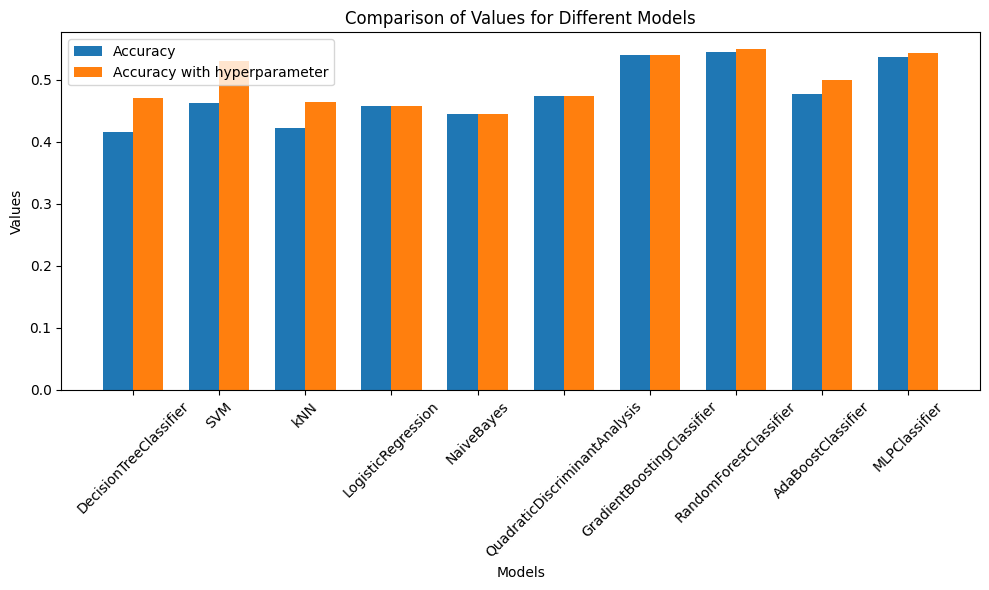

In [55]:
# Assuming models_pred is a dictionary with key-value pairs
# where key is the model name and values are two numeric values


model_names = []
score = []
score_rs = []

for key, values in models_pred.items():
    model_names.append(key)
    score.append(accuracy_score(y_test, values[0]))
    score_rs.append(accuracy_score(y_test, values[1]))

fig, ax = plt.subplots(figsize=(10, 6))

bar_width = 0.35
index = np.arange(len(model_names))

bar1 = ax.bar(index - bar_width/2, score, bar_width, label='Accuracy')
bar2 = ax.bar(index + bar_width/2, score_rs, bar_width, label='Accuracy with hyperparameter')

ax.set_xlabel('Models')
ax.set_ylabel('Values')
ax.set_title('Comparison of Values for Different Models')
ax.set_xticks(index)
ax.set_xticklabels(model_names, rotation=45)
ax.legend()
    
plt.tight_layout()    
plt.show()